In [17]:
from scipy.special import erfc
import numpy as np
import matplotlib.pyplot as plt

In [18]:
#Gaussian
def gaussian(x, amp1, cen1, wid1):
    norm = wid1 * np.sqrt(2 * np.pi)
    return amp1 * np.exp(-(x-cen1)**2 / (2*wid1**2)) / norm

def two_gaussians(x, amp1, cen1, wid1, amp2, cen2, wid2):
    g1 = gaussian(x, amp1, cen1, wid1)
    g2 = gaussian(x, amp2, cen2, wid2)
    return g1+g2

In [19]:
#pseudo-voigt (normalized)
def pseudo_voigt(x, amp, cen, wid, eta):
    # Normalized Gaussian and Lorentzian components
    norm_gauss = wid * np.sqrt(2 * np.pi)
    norm_lorentz = np.pi * wid
    gaussian = amp * np.exp(-((x - cen)**2) / (2 * wid**2)) / norm_gauss
    lorentzian = amp * (wid**2 / ((x - cen)**2 + wid**2)) / norm_lorentz
    return eta * lorentzian + (1 - eta) * gaussian

def two_pseudo_voigts(x, amp1, cen1, wid1, eta1, amp2, cen2, wid2, eta2):
    pv1 = pseudo_voigt(x, amp1, cen1, wid1, eta1)
    pv2 = pseudo_voigt(x, amp2, cen2, wid2, eta2)
    return pv1 + pv2

In [20]:
#Exponentially modified gaussian --> Tailing
def EMG(x, h, mu, sigma, tau):
    prefactor = (h* 0.5*tau)
    exp_arg = (0.5*tau *(2*mu+tau*sigma**2-2*x))
    erfc_arg = (mu+tau*sigma**2-x)/(np.sqrt(2)*sigma)
    return prefactor * np.exp(exp_arg) * erfc(erfc_arg)

#Mirrored Exponentially modified gaussian --> Fronting
def EMG_mirrored(x, h, mu, sigma, tau):
    return EMG(-x,h,-mu,sigma,tau)

#EMG + mirrored EMG
def EMGsTailFront(x, h1, mu1, sigma1, tau1, h2, mu2, sigma2, tau2):
    Tail_EMG = EMG(x, h1, mu1, sigma1, tau1)
    Front_EMG = EMG_mirrored(x, h2, mu2, sigma2, tau2)
    return Tail_EMG+Front_EMG

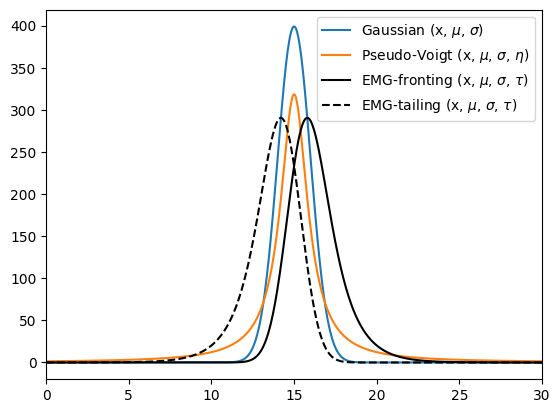

In [30]:
x           = np.linspace(0, 30, 1001)
y_EMG       = EMG(x, h=1e3, mu=15, sigma=1, tau=0.8)
y_EMG_mirr  = EMG_mirrored(x, h=1e3, mu=15, sigma=1, tau=0.8)
y_gauss     = gaussian(x, amp1=1e3, cen1=15, wid1=1)
y_pv        = pseudo_voigt(x, amp=1e3, cen=15,wid=1, eta=1)

plt.plot(x, y_gauss,    'C0-', label = r'Gaussian (x, $\mu$, $\sigma$)')
plt.plot(x, y_pv,       'C1-', label = r'Pseudo-Voigt (x, $\mu$, $\sigma$, $\eta$)')
plt.plot(x, y_EMG,      'k-' , label = r'EMG-fronting (x, $\mu$, $\sigma$, $\tau$)') 
plt.plot(x, y_EMG_mirr, 'k--', label = r'EMG-tailing (x, $\mu$, $\sigma$, $\tau$)') 
plt.xlim(0, 30)
plt.legend()
plt.show()